# About this notebook
1. This notebook prepares GeoJSON files to match Trivedi Centre for Political Data (TCPD) IDs. **To display Election Data and Capex in a Choropleth** 
2. Load raw GeoJSON, and Save JSON --> Excel
3. Add Unique identifiers in GeoJson properties for States, Districts, Parliamentary Constituency PC, Assembly.
4. Unique identifiers help match geography info with election data from TCPD and Projects data from CMIE Capex .
4. Reload new GeoJSON and visualize maps



In [4]:
# Project folder
proj_folder = "/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/Capex/"
shapefiles_raw = "/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/Capex/shape-files/1.raw"
shapefiles_interim = "/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/Capex/shape-files/2.interim"
shapefiles_cleaned = "/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/Capex/shape-files/3.cleaned"

#State Input files and folders 
st_old_geo_file = "shape-files/1.raw/india_state-V2.json"
st_geo_file ="shape-files/1.raw/INDIA_STATES.geojson"
# District files and folders 
dist_old_geo_file = "shape-files/1.raw/india_2011_district-V2.json"
dist_geo_file = "shape-files/1.raw/INDIA_DISTRICTS.geojson"
# Parliament Constituency files and folders 
pc_old_geo_file = "shape-files/1.raw/india_2014_parliament-V2.json"
pc_geo_file = "shape-files/1.raw/india_2014_parliament-V3.json"
# Assembly Constituency files and folders 
ac_geo_file = "shape-files/1.raw/india_2012-17_assembly-V2.json"

print('Folder and File Names set-up')


Folder and File Names set-up


## Load JSON and Save in Excel: Run Once

In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

# File Name - GeoJSON file
st_file_path= os.path.join(proj_folder, st_geo_file)
dist_file_path= os.path.join(proj_folder, dist_geo_file)
pc_file_path= os.path.join(proj_folder, pc_geo_file)
ac_file_path= os.path.join(proj_folder, ac_geo_file)


# Read the GeoJSON file into a GeoDataFrame
st_gdf = gpd.read_file(st_file_path)
dist_gdf = gpd.read_file(dist_file_path)
pc_gdf = gpd.read_file(pc_file_path)
ac_gdf = gpd.read_file(ac_file_path)


# Save the unique values to an Excel file
st_gdf.to_excel(os.path.join(shapefiles_raw, 'st_geo.xlsx'), index=False)
dist_gdf.to_excel(os.path.join(shapefiles_raw, 'dist_geo.xlsx'), index=False)
pc_gdf.to_excel(os.path.join(shapefiles_raw, 'pc_geo.xlsx'), index=False)
ac_gdf.to_excel(os.path.join(shapefiles_raw, 'ac_geo.xlsx'), index=False)

print('FINITO: JSON ---> Excel')

FINITO: JSON ---> Excel


DO MANUAL EDIT TO CREATE Unique Identifiers

## Clean Districts GeoJSON

/var/folders/z8/88j49zkx5dx5mcwzhksyz88r0000gn/T/ipykernel_49457/3367810905.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = group.geometry.representative_point().distance(state_center)
/var/folders/z8/88j49zkx5dx5mcwzhksyz88r0000gn/T/ipykernel_49457/3367810905.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = group.geometry.representative_point().distance(state_center)
/var/folders/z8/88j49zkx5dx5mcwzhksyz88r0000gn/T/ipykernel_49457/3367810905.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = group.geometry.representative_po

New 'Multi-district' entries have been created successfully.
new GeoJSON saved


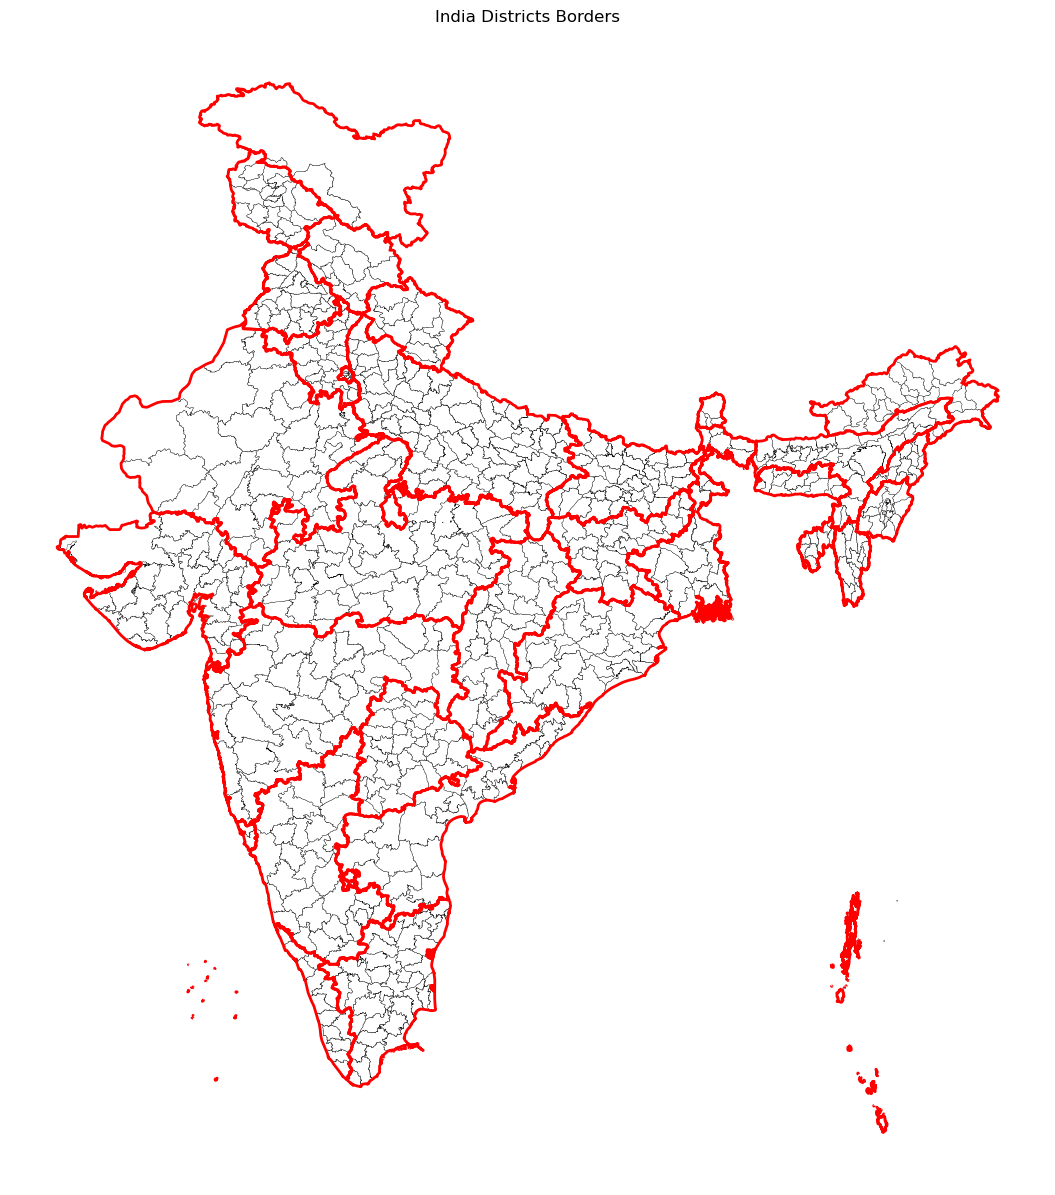

District UID Excel Saved
Finito


In [33]:
import geopandas as gpd

# Load the GeoJSON file into a GeoDataFrame
dist_file_path = os.path.join(proj_folder, dist_geo_file)
dist_gdf = gpd.read_file(dist_file_path)
states_gdf = gpd.read_file(st_file_path)


# # Define the list of conditions and their corresponding new values
conditions = [
{'match':'GUJARAT', 'new_value':'GJ-S07'},
{'match':'MADHYA PRADESH', 'new_value':'MP-S13'},
{'match':'UTTAR PRADESH', 'new_value':'UP-S26'},
{'match':'RAJASTHAN', 'new_value':'RJ-S21'},
{'match':'KERALA', 'new_value':'KL-S12'},
{'match':'UTTARAKHAND', 'new_value':'UK-S27'},
{'match':'ODISHA', 'new_value':'OD-S19'},
{'match':'KARNATAKA', 'new_value':'KA-S11'},
{'match':'CHHATTISGARH', 'new_value':'CG-S05'},
{'match':'HIMACHAL PRADESH', 'new_value':'HP-S09'},
{'match':'MANIPUR', 'new_value':'MN-S15'},
{'match':'JHARKHAND', 'new_value':'JH-S10'},
{'match':'DELHI', 'new_value':'DL-U04'},
{'match':'CHANDIGARH', 'new_value':'CH-U02'},
{'match':'DADRA,NAGAR HAVELI,DAMAN & DIU', 'new_value':'DN-U03A'},
{'match':'DADRA,NAGAR HAVELI,DAMAN & DIU', 'new_value':'DD-U03B'},
{'match':'TRIPURA', 'new_value':'TR-S25'},
{'match':'ASSAM', 'new_value':'AS-S03'},
{'match':'SIKKIM', 'new_value':'SK-S22'},
{'match':'MEGHALAYA', 'new_value':'ML-S16'},
{'match':'PUDUCHERRY', 'new_value':'PY-U08'},
{'match':'LAKSHADWEEP', 'new_value':'LD-U07'},
{'match':'ANDAMAN & NICOBAR', 'new_value':'AN-U01'},
{'match':'GOA', 'new_value':'GA-S06'},
{'match':'MIZORAM', 'new_value':'MZ-S17'},
{'match':'JAMMU & KASHMIR', 'new_value':'JK-U05'},
{'match':'LADAKH', 'new_value':'LK-U06'},
{'match':'TELANGANA', 'new_value':'TS-S24'},
{'match':'MAHARASHTRA', 'new_value':'MH-S14'},
{'match':'WEST BENGAL', 'new_value':'WB-S28'},
{'match':'HARYANA', 'new_value':'HR-S08'},
{'match':'PUNJAB', 'new_value':'PB-S20'},
{'match':'ARUNACHAL PRADESH', 'new_value':'AR-S02'},
{'match':'BIHAR', 'new_value':'BR-S04'},
{'match':'NAGALAND', 'new_value':'NL-S18'},
{'match':'TAMIL NADU', 'new_value':'TN-S23'},
{'match':'ANDHRA PRADESH', 'new_value':'AP-S01'},
]

# Add a new property 'new_property' with a default value
dist_gdf['ST_UID'] = 'NA'

# Rename multiple columns
dist_gdf = dist_gdf.rename(columns={'stname': 'ST_NAME', 'dtname': 'DT_NAME'})

# Modify the new property based on the list of conditions
for idx, row in dist_gdf.iterrows():
    for condition in conditions:
        if row['ST_NAME'] == condition['match']:  # Replace 'existing_property' with the actual column name
            dist_gdf.at[idx, 'ST_UID'] = condition['new_value']
            break  # Exit the loop after the first match to avoid overwriting

# Sort the DataFrame by 'st_id' and 'dtname'
dist_gdf = dist_gdf.sort_values(by=['ST_UID', 'DT_NAME']).reset_index(drop=True)

# Group by 'st_id' and create a serial number for each district within each group
dist_gdf['serial_no'] = dist_gdf.groupby('ST_UID').cumcount() + 1

# Convert the serial number to a string and pad with zeros to have four digits
dist_gdf['serial_no'] = dist_gdf['serial_no'].astype(str).str.zfill(3)

# Create the unique ID string by concatenating 'st_id' and the zero-padded serial number
dist_gdf['DT_UID'] = dist_gdf['ST_UID'] + '-DT-' + dist_gdf['serial_no']

# Drop the 'serial_no' column as it is no longer needed
dist_gdf = dist_gdf.drop(columns=['serial_no'])

# converting and overwriting values in column
dist_gdf["ST_NAME"]= dist_gdf["ST_NAME"].str.upper().str.title()

#################################################################
# Create another entry for every state that has the same ST_UID
#################################################################

# Group by state and create the new entries
multi_dist_rows = []

# Group by state to find the central district in each
for st_uid, group in dist_gdf.groupby('ST_UID'):
    
    # --- Step 1: Find the center of the state to determine the central district ---
    # We create the state's full geometry only to find its center point
    state_geometry = group.geometry.buffer(0).union_all()
    state_center = state_geometry.representative_point()
    
    # --- Step 2: Find the district closest to that center point ---
    distances = group.geometry.representative_point().distance(state_center)
    center_district_index = distances.idxmin()
    center_district = group.loc[center_district_index]
    
    # --- Step 3: Create the new 'Multi-district' entry ---
    new_row = {
        'ST_UID': st_uid,
        'ST_NAME': center_district['ST_NAME'],
        'DT_NAME': f"Multi districts - {center_district['ST_NAME']}",
        'DT_UID': f"{st_uid}-DT-MUL",
        
        # --- Step 4: Assign the geometry OF THE CENTRAL DISTRICT to the new entry ---
        'geometry': center_district.geometry
    }
    multi_dist_rows.append(new_row)

# Create a new GeoDataFrame from our list of new rows
multi_dist_gdf = gpd.GeoDataFrame(multi_dist_rows, crs=dist_gdf.crs)

# Combine the original districts with the new 'Multi-district' entries
final_gdf = pd.concat([dist_gdf, multi_dist_gdf], ignore_index=True)

# Sort the result for clean, predictable ordering
final_gdf = final_gdf.sort_values(by=['ST_UID', 'DT_UID']).reset_index(drop=True)

print("New 'Multi-district' entries have been created successfully.")

#################################################################

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_cleaned, 'india_districts_cleaned-V1.geojson')
final_gdf.to_file(output_file_path, driver='GeoJSON')

print('new GeoJSON saved')
##############
# Read the just saved new GeoJSON file into a GeoDataFrame
gdf = gpd.read_file(output_file_path)

# Create a plot
fig, ax = plt.subplots(figsize=(15, 15))
# Set the background color of the figure
fig.patch.set_facecolor('white')  # Change 'lightblue' to your preferred color

# Plot the districts with a thin border
# districts_gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.25)

# Plot the state borders with a thicker line
states_gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=2)

# # Loop through each geometry and add text annotations for "ST_UID"
# for idx, row in gdf.iterrows():
#     # Get the geometry's representative point (centroid)
#     point = row.geometry.representative_point()
#     # Use the `ax.annotate` method to add text annotations
#     ax.annotate(text=row['DT_UID'], xy=(point.x, point.y), horizontalalignment='center', fontsize=4)

# Remove the axis for a cleaner look
ax.axis('off')
# Set the title
plt.title('India Districts Borders')
# Display the plot
plt.show()

# create excel with geo unique ids for cross-check and verification
df = final_gdf[['DT_NAME', 'DT_UID','ST_UID', 'ST_NAME']].drop_duplicates()
df = df.sort_values(by=['DT_UID']).reset_index(drop=True)

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_interim, 'dist_geo_uid.xlsx')
df.to_excel(output_file_path, sheet_name="dist-geo-uid")

print('District UID Excel Saved')

print('Finito')


## Clean Parliamentary Constituency GeoJSON

new GeoJSON saved


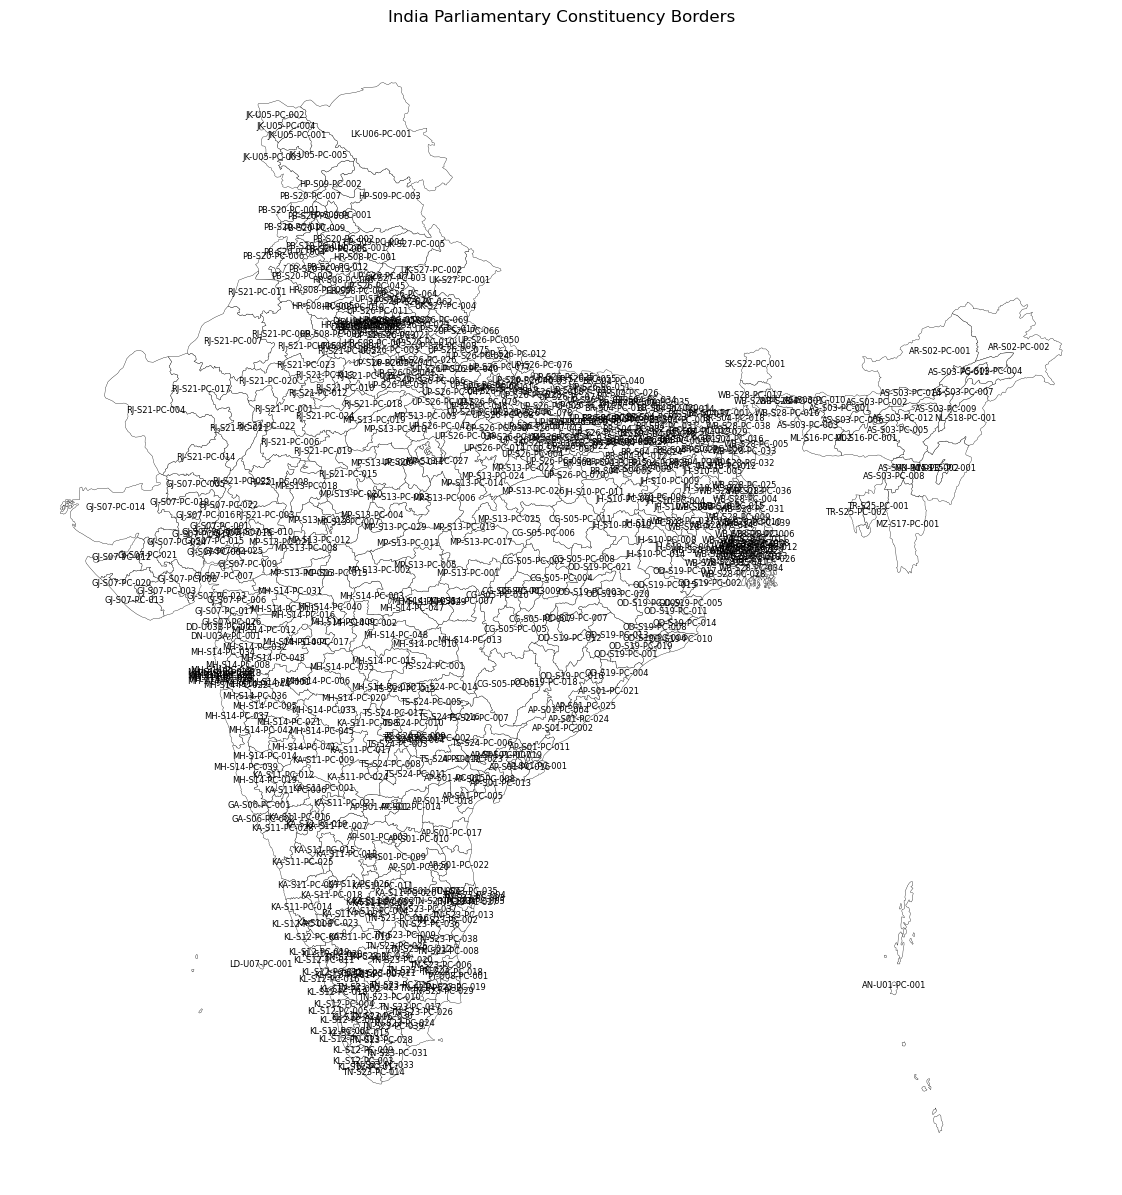

Parliament Constituency UID Excel Saved
Finito


In [55]:
import geopandas as gpd

# Load the GeoJSON file into a GeoDataFrame
pc_file_path= os.path.join(proj_folder, pc_geo_file)
pc_gdf = gpd.read_file(pc_file_path)
st_file_path = os.path.join(proj_folder, st_geo_file) 
states_gdf = gpd.read_file(st_file_path)


# Add a new property 'new_property' with a default value
pc_gdf['ST_UID'] = pc_gdf['ST_ABB'] + '-' + pc_gdf['ST_CODE']

# Sort the DataFrame by 'st_id' and 'dtname'
pc_gdf = pc_gdf.sort_values(by=['ST_UID', 'PC_NAME']).reset_index(drop=True)

# Group by 'st_id' and create a serial number for each district within each group
pc_gdf['serial_no'] = pc_gdf.groupby('ST_UID').cumcount() + 1

# Convert the serial number to a string and pad with zeros to have four digits
pc_gdf['serial_no'] = pc_gdf['serial_no'].astype(str).str.zfill(3)

# Create the unique ID string by concatenating 'st_id' and the zero-padded serial number
pc_gdf['PC_UID'] = pc_gdf['ST_UID'] + '-PC-' + pc_gdf['serial_no']

# Drop the 'serial_no' column as it is no longer needed
pc_gdf = pc_gdf.drop(columns=['serial_no'])


# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_cleaned, 'india_pc_cleaned-V1.geojson')
pc_gdf.to_file(output_file_path, driver='GeoJSON')

print('new GeoJSON saved')
##############
# Read the just saved new GeoJSON file into a GeoDataFrame
gdf = gpd.read_file(output_file_path)

# Create a plot
fig, ax = plt.subplots(figsize=(15, 15))
# Set the background color of the figure
fig.patch.set_facecolor('white')  # Change 'lightblue' to your preferred color

# Plot the districts with a thin border
# districts_gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.25)

# Plot the state borders with a thicker line
# states_gdf.boundary.plot(ax=ax, edgecolor='blue', linewidth=1)

# Loop through each geometry and add text annotations for "ST_UID"
for idx, row in gdf.iterrows():
    # Get the geometry's representative point (centroid)
    point = row.geometry.representative_point()
    # Use the `ax.annotate` method to add text annotations
    ax.annotate(text=row['PC_UID'], xy=(point.x, point.y), horizontalalignment='center', fontsize=6)


# Remove the axis for a cleaner look
ax.axis('off')
# Set the title
plt.title('India Parliamentary Constituency Borders')
# Display the plot
plt.show()

# Export excel with geo unique ids for cross-check and verification

df = pc_gdf[['ST_UID', 'ST_NAME', 'PC_UID', 'PC_NAME',]].drop_duplicates()
df = df.sort_values(by=['PC_UID']).reset_index(drop=True)

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_interim, 'pc_geo_uid.xlsx')
df.to_excel(output_file_path, sheet_name="pc-geo-uid")

print('Parliament Constituency UID Excel Saved')

print('Finito')


## Clean Assembly Constituency GeoJSON

Index(['ST_CODE', 'ST_NAME', 'DT_CODE', 'DIST_NAME', 'AC_NO', 'AC_NAME',
       'PC_NO', 'PC_NAME', 'geometry'],
      dtype='object')
new GeoJSON saved


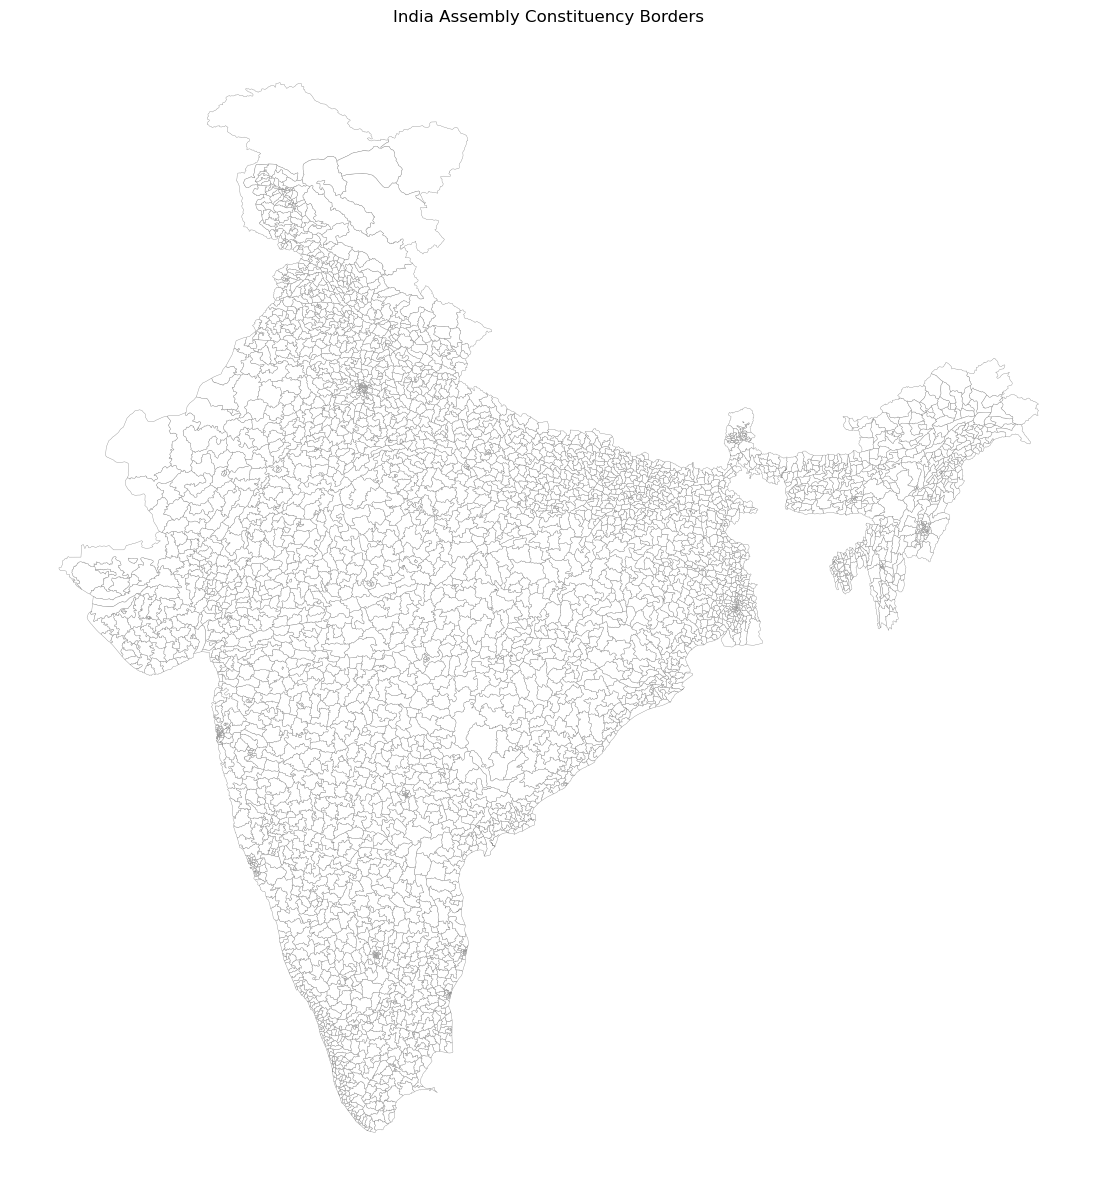

Finito


In [59]:
import geopandas as gpd

# Load the GeoJSON file into a GeoDataFrame
ac_file_path= os.path.join(proj_folder, ac_geo_file)
ac_gdf = gpd.read_file(ac_file_path)
states_gdf = gpd.read_file(st_file_path)

print(ac_gdf.columns)
# # Define the list of conditions and their corresponding new values
conditions = [
{'match':'GUJARAT', 'new_value':'GJ-S07'},
{'match':'MADHYA PRADESH', 'new_value':'MP-S13'},
{'match':'UTTAR PRADESH', 'new_value':'UP-S26'},
{'match':'RAJASTHAN', 'new_value':'RJ-S21'},
{'match':'KERALA', 'new_value':'KL-S12'},
{'match':'UTTARAKHAND', 'new_value':'UK-S27'},
{'match':'ODISHA', 'new_value':'OD-S19'},
{'match':'KARNATAKA', 'new_value':'KA-S11'},
{'match':'CHHATTISGARH', 'new_value':'CG-S05'},
{'match':'HIMACHAL PRADESH', 'new_value':'HP-S09'},
{'match':'MANIPUR', 'new_value':'MN-S15'},
{'match':'JHARKHAND', 'new_value':'JH-S10'},
{'match':'DELHI', 'new_value':'DL-U04'},
{'match':'CHANDIGARH', 'new_value':'CH-U02'},
{'match':'DADRA,NAGAR HAVELI,DAMAN & DIU', 'new_value':'DN-U03A'},
{'match':'DADRA,NAGAR HAVELI,DAMAN & DIU', 'new_value':'DD-U03B'},
{'match':'TRIPURA', 'new_value':'TR-S25'},
{'match':'ASSAM', 'new_value':'AS-S03'},
{'match':'SIKKIM', 'new_value':'SK-S22'},
{'match':'MEGHALAYA', 'new_value':'ML-S16'},
{'match':'PUDUCHERRY', 'new_value':'PY-U08'},
{'match':'LAKSHADWEEP', 'new_value':'LD-U07'},
{'match':'ANDAMAN & NICOBAR', 'new_value':'AN-U01'},
{'match':'GOA', 'new_value':'GA-S06'},
{'match':'MIZORAM', 'new_value':'MZ-S17'},
{'match':'JAMMU & KASHMIR', 'new_value':'JK-U05'},
{'match':'LADAKH', 'new_value':'LK-U06'},
{'match':'TELANGANA', 'new_value':'TS-S24'},
{'match':'MAHARASHTRA', 'new_value':'MH-S14'},
{'match':'WEST BENGAL', 'new_value':'WB-S28'},
{'match':'HARYANA', 'new_value':'HR-S08'},
{'match':'PUNJAB', 'new_value':'PB-S20'},
{'match':'ARUNACHAL PRADESH', 'new_value':'AR-S02'},
{'match':'BIHAR', 'new_value':'BR-S04'},
{'match':'NAGALAND', 'new_value':'NL-S18'},
{'match':'TAMIL NADU', 'new_value':'TN-S23'},
{'match':'ANDHRA PRADESH', 'new_value':'AP-S01'},
]

# Add a new property 'new_property' with a default value
ac_gdf['ST_UID'] = 'NA'

# Modify the new property based on the list of conditions
for idx, row in ac_gdf.iterrows():
    for condition in conditions:
        if row['ST_NAME'] == condition['match']:  # Replace 'existing_property' with the actual column name
            ac_gdf.at[idx, 'ST_UID'] = condition['new_value']
            break  # Exit the loop after the first match to avoid overwriting
            

# Sort the DataFrame by 'st_id' and 'dtname'
ac_gdf = ac_gdf.sort_values(by=['ST_UID', 'AC_NAME']).reset_index(drop=True)

# Group by 'st_id' and create a serial number for each district within each group
ac_gdf['serial_no'] = ac_gdf.groupby('ST_UID').cumcount() + 1

# Convert the serial number to a string and pad with zeros to have four digits
ac_gdf['serial_no'] = ac_gdf['serial_no'].astype(str).str.zfill(3)

# Create the unique ID string by concatenating 'st_id' and the zero-padded serial number
ac_gdf['AC_UID'] = ac_gdf['ST_UID'] + '-AC-' + ac_gdf['serial_no']

# Drop the 'serial_no' column as it is no longer needed
ac_gdf = ac_gdf.drop(columns=['serial_no'])


# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_cleaned, 'india_ac_cleaned-V1.geojson')
ac_gdf.to_file(output_file_path, driver='GeoJSON')

print('new GeoJSON saved')
##############
# Read the just saved new GeoJSON file into a GeoDataFrame
gdf = gpd.read_file(output_file_path)

# Create a plot
fig, ax = plt.subplots(figsize=(15, 15))
# Set the background color of the figure
fig.patch.set_facecolor('white')  # Change 'lightblue' to your preferred color

# Plot the districts with a thin border
# districts_gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
gdf.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.25)

# Plot the state borders with a thicker line
# states_gdf.boundary.plot(ax=ax, edgecolor='green', linewidth=1)

# Loop through each geometry and add text annotations for "AC_UID"
# for idx, row in gdf.iterrows():
#     # Get the geometry's representative point (centroid)
#     point = row.geometry.representative_point()
#     # Use the `ax.annotate` method to add text annotations
#     ax.annotate(text=row['AC_UID'], xy=(point.x, point.y), horizontalalignment='center', fontsize=3)


# Remove the axis for a cleaner look
ax.axis('off')
# Set the title
plt.title('India Assembly Constituency Borders')
# Display the plot
plt.show()

print('Finito')


ST_NAME     0
PC_NAME    32
dtype: int64
new GeoJSON saved


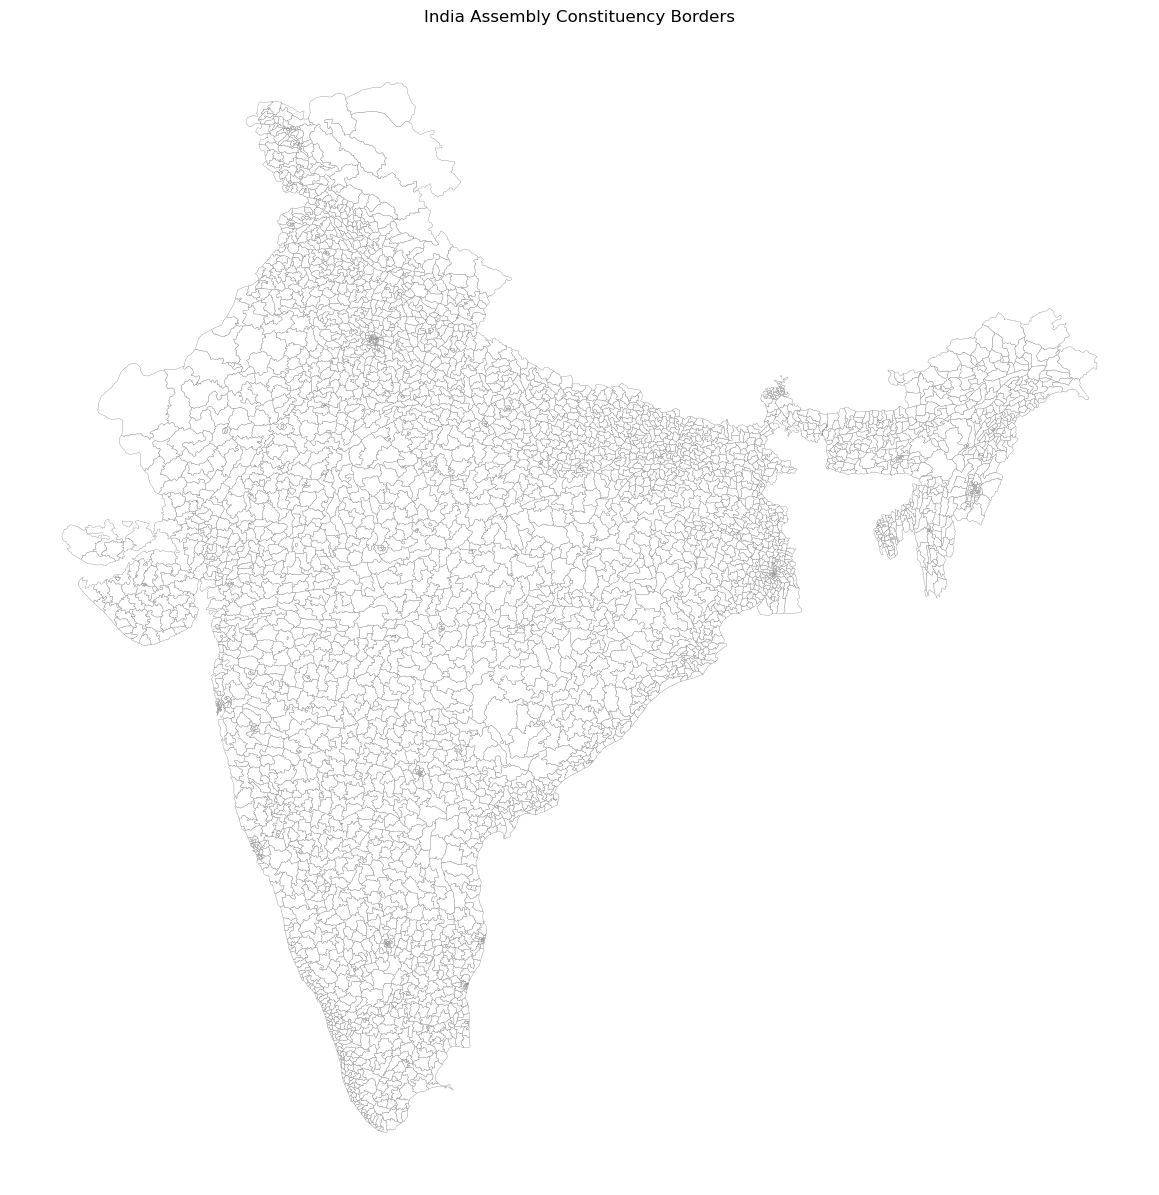

Assembly Constituency UID Excel Saved
Finito


In [104]:
import geopandas as gpd

# Load the GeoJSON file into a GeoDataFrame
ac_file_path= os.path.join(proj_folder, "shape-files/1.raw/india_2012-17_assembly-V3.json")
ac_gdf = gpd.read_file(ac_file_path)
states_gdf = gpd.read_file(st_file_path)

# # Define the list of conditions and their corresponding new values
conditions = [
{'match':'GUJARAT', 'new_value':'GJ-S07'},
{'match':'MADHYA PRADESH', 'new_value':'MP-S13'},
{'match':'UTTAR PRADESH', 'new_value':'UP-S26'},
{'match':'RAJASTHAN', 'new_value':'RJ-S21'},
{'match':'KERALA', 'new_value':'KL-S12'},
{'match':'UTTARAKHAND', 'new_value':'UK-S27'},
{'match':'ODISHA', 'new_value':'OD-S19'},
{'match':'KARNATAKA', 'new_value':'KA-S11'},
{'match':'CHHATTISGARH', 'new_value':'CG-S05'},
{'match':'HIMACHAL PRADESH', 'new_value':'HP-S09'},
{'match':'MANIPUR', 'new_value':'MN-S15'},
{'match':'JHARKHAND', 'new_value':'JH-S10'},
{'match':'DELHI', 'new_value':'DL-U04'},
{'match':'CHANDIGARH', 'new_value':'CH-U02'},
{'match':'DADRA,NAGAR HAVELI,DAMAN & DIU', 'new_value':'DN-U03A'},
{'match':'DADRA,NAGAR HAVELI,DAMAN & DIU', 'new_value':'DD-U03B'},
{'match':'TRIPURA', 'new_value':'TR-S25'},
{'match':'ASSAM', 'new_value':'AS-S03'},
{'match':'SIKKIM', 'new_value':'SK-S22'},
{'match':'MEGHALAYA', 'new_value':'ML-S16'},
{'match':'PUDUCHERRY', 'new_value':'PY-U08'},
{'match':'LAKSHADWEEP', 'new_value':'LD-U07'},
{'match':'ANDAMAN & NICOBAR', 'new_value':'AN-U01'},
{'match':'GOA', 'new_value':'GA-S06'},
{'match':'MIZORAM', 'new_value':'MZ-S17'},
{'match':'JAMMU & KASHMIR', 'new_value':'JK-U05'},
{'match':'LADAKH', 'new_value':'LK-U06'},
{'match':'TELANGANA', 'new_value':'TS-S24'},
{'match':'MAHARASHTRA', 'new_value':'MH-S14'},
{'match':'WEST BENGAL', 'new_value':'WB-S28'},
{'match':'HARYANA', 'new_value':'HR-S08'},
{'match':'PUNJAB', 'new_value':'PB-S20'},
{'match':'ARUNACHAL PRADESH', 'new_value':'AR-S02'},
{'match':'BIHAR', 'new_value':'BR-S04'},
{'match':'NAGALAND', 'new_value':'NL-S18'},
{'match':'TAMIL NADU', 'new_value':'TN-S23'},
{'match':'ANDHRA PRADESH', 'new_value':'AP-S01'},
]


# Add a new property 'new_property' with a default value
ac_gdf['ST_UID'] = 'NA'

# Modify the new property based on the list of conditions
for idx, row in ac_gdf.iterrows():
    for condition in conditions:
        if row['ST_NAME'] == condition['match']:  # Replace 'existing_property' with the actual column name
            ac_gdf.at[idx, 'ST_UID'] = condition['new_value']
            break  # Exit the loop after the first match to avoid overwriting

# Sort the DataFrame by 'st_id', 'dtname', and 'sub-dist'
ac_gdf = ac_gdf.sort_values(by=['ST_UID', 'PC_NAME', 'AC_NAME']).reset_index(drop=True)

print(ac_gdf[['ST_NAME', 'PC_NAME']].isna().sum())

ac_gdf = ac_gdf.dropna(subset=['ST_NAME', 'PC_NAME','AC_NAME'])

# Generate pc_no: counter starts at 1 within each ST_UID
ac_gdf['pc_no'] = (
    ac_gdf.groupby('ST_UID')['PC_NAME']
    .transform(lambda x: pd.factorize(x)[0] + 1)
)

# Generate ac_no: counter starts at 1 within each ST_UID + PC_NAME
ac_gdf['ac_no'] = (
    ac_gdf.groupby(['ST_UID', 'PC_NAME'])['AC_NAME']
    .transform(lambda x: pd.factorize(x)[0] + 1)
)

# Convert to string with left-filled zeros
ac_gdf['pc_no'] = ac_gdf['pc_no'].astype(int).astype(str).str.zfill(3)
ac_gdf['ac_no'] = ac_gdf['ac_no'].astype(int).astype(str).str.zfill(3)


# Create the unique district code by concatenating 'st_id' and the zero-padded district number
ac_gdf['PC_UID'] = ac_gdf['ST_UID'] + '-PC-' + ac_gdf['pc_no']

# Create the unique sub-district code by concatenating 'unique_district_code' and the zero-padded sub-district number
ac_gdf['AC_UID'] = ac_gdf['PC_UID'] + '-AC-' + ac_gdf['ac_no']

# print results
# print(ac_gdf[['ST_UID', 'PC_NAME', 'AC_NAME', 'PC_UID', 'AC_UID', 'pc_no', 'ac_no']])

# Drop the intermediate columns 'district_no' and 'sub_district_no' as they are no longer needed
ac_gdf = ac_gdf.drop(columns=['pc_no', 'ac_no'])

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_cleaned, 'india_ac_cleaned-V2.geojson')
ac_gdf.to_file(output_file_path, driver='GeoJSON')

print('new GeoJSON saved')
##############
# Read the saved new GeoJSON file into a GeoDataFrame
gdf = gpd.read_file(output_file_path)

# Create a plot
fig, ax = plt.subplots(figsize=(15, 15))
# Set the background color of the figure
fig.patch.set_facecolor('white')  # Change 'lightblue' to your preferred color

# Plot the districts with a thin border
# districts_gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
gdf.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.25)

# Plot the state borders with a thicker line
# states_gdf.boundary.plot(ax=ax, edgecolor='green', linewidth=1)

# Remove the axis for a cleaner look
ax.axis('off')
# Set the title
plt.title('India Assembly Constituency Borders')
# Display the plot
plt.show()

# Export excel with geo unique ids for cross-check and verification

df = ac_gdf[['ST_UID', 'ST_NAME', 'PC_UID', 'PC_NAME', 'AC_UID', 'AC_NAME']].drop_duplicates()
df = df.sort_values(by=['AC_UID']).reset_index(drop=True)

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_interim, 'ac_geo_uid.xlsx')
df.to_excel(output_file_path, sheet_name="ac-geo-uid")

print('Assembly Constituency UID Excel Saved')

print('Finito')


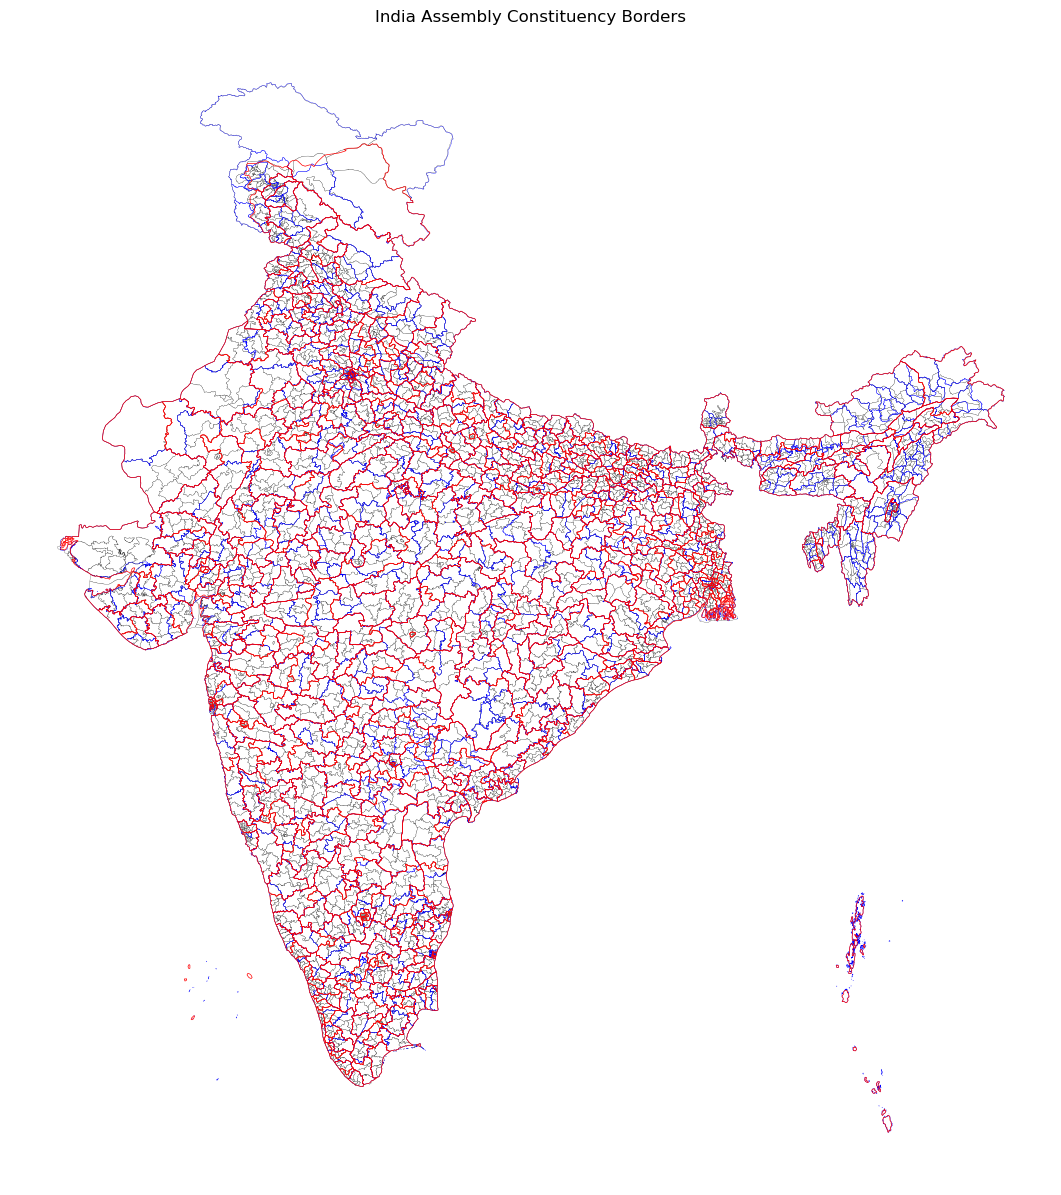

In [19]:
import geopandas as gpd
import os

# Load the GeoJSON file into a GeoDataFrame
new_ac_file_path= os.path.join(proj_folder, "shape-files/1.raw/ac.geojson")
ac_gdf = gpd.read_file(new_ac_file_path)
dist_file_path = os.path.join(proj_folder, dist_geo_file)
dist_gdf = gpd.read_file(dist_file_path)
pc_file_path= os.path.join(proj_folder, pc_geo_file)
pc_gdf = gpd.read_file(pc_file_path)
states_gdf = gpd.read_file(st_file_path)


# Create a plot
fig, ax = plt.subplots(figsize=(15, 15))
# Set the background color of the figure
fig.patch.set_facecolor('white')  # Change 'lightblue' to your preferred color

# Plot the districts with a thin border
ac_gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.15)

# Plot the state borders with a thicker line
dist_gdf.boundary.plot(ax=ax, edgecolor='blue', linewidth=0.25)
pc_gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=0.5)
# states_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# Remove the axis for a cleaner look
ax.axis('off')
# Set the title
plt.title('India Assembly Constituency Borders')
# Display the plot
plt.show()

# 3A. Export the attributes to Excel for manual editing:
ac_gdf = ac_gdf[['ST_CODE', 'ST_NAME', 'PC_NO', 'PC_NAME', 'DT_CODE', 'DIST_NAME', 'AC_NO', 'AC_NAME']].drop_duplicates()
ac_gdf = ac_gdf.sort_values(by=['ST_NAME','PC_NAME','AC_NAME', 'DIST_NAME']).reset_index(drop=True)


# 3B. Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_interim, 'ac_geo_uid_tmp.xlsx')
ac_gdf.to_excel(output_file_path, sheet_name="ac-geo-uid", index=False)



# Manual Edit properties to be merged with and create Final AC geojson

In [106]:
# Continuation from previous code block 

# 3C. Next Manually edit the Excel file named ac_uid_geo_augmented.xslx in the shapefiles_interim folder

# 4. Reload and merge back with the original geometry
import geopandas as gpd
import pandas as pd
import os

# Load the GeoJSON file into a GeoDataFrame
geojson_file = os.path.join(proj_folder, "shape-files/3.cleaned/india_ac_cleaned-V2.geojson")
excel_file = os.path.join(proj_folder, "shape-files/2.interim/ac_geo_uid_augmented.xlsx")

# Load geojson
gdf = gpd.read_file(geojson_file)
# Print its columns
print("GeoJSON columns:")
print(gdf.columns)

# Load Excel
df = pd.read_excel(excel_file, sheet_name="clean")

# Sort the DataFrame by 'st_id' and 'dtname'
df = df.sort_values(by=['ST_UID', 'DT_NAME']).reset_index(drop=True)

print(df[['ST_UID', 'DT_NAME']].isna().sum())


# Generate dt_no: counter starts at 1 within each ST_UID 
df['dt_no'] = (
    df.groupby(['ST_UID'])['DT_NAME']
    .transform(lambda x: pd.factorize(x)[0] + 1)
)

# Convert to string with left-filled zeros
df['dt_no'] = df['dt_no'].astype(int).astype(str).str.zfill(3)

# Create the unique district code by concatenating 'st_id' and the zero-padded district number
df['DT_UID'] = df['ST_UID'] + '-DT-' + df['dt_no']

# print results
# print(df[['ST_UID', 'PC_NAME', 'AC_NAME', 'PC_UID', 'AC_UID', 'DT_UID']])

# Drop the intermediate columns 'district_no' and 'sub_district_no' as they are no longer needed
df = df.drop(columns=['dt_no'])

# Merge: keep geometry from gdf, columns from df
# This effectively replaces ALL attributes from the geojson
# with the excel data while keeping geometry
new_gdf = df.merge(
    gdf[["AC_UID", "geometry"]],
    on="AC_UID",
    how="left"
)

# convert to a GeoDataFrame
final_gdf = gpd.GeoDataFrame(new_gdf, geometry="geometry", crs=gdf.crs)

# 5. Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_cleaned, 'india_ac_cleaned-V3.geojson')
final_gdf.to_file(output_file_path, driver="GeoJSON")

print("Updated GeoJSON saved with new properties from Excel!")

print('NEW (V3) Assembly Constituency UID Excel Saved')

print('Finito')

GeoJSON columns:
Index(['ST_CODE', 'ST_NAME', 'DT_CODE', 'DIST_NAME', 'AC_NO', 'AC_NAME',
       'PC_NO', 'PC_NAME', 'ST_UID', 'PC_UID', 'AC_UID', 'geometry'],
      dtype='object')
ST_UID     0
DT_NAME    0
dtype: int64
Updated GeoJSON saved with new properties from Excel!
NEW (V3) Assembly Constituency UID Excel Saved
Finito


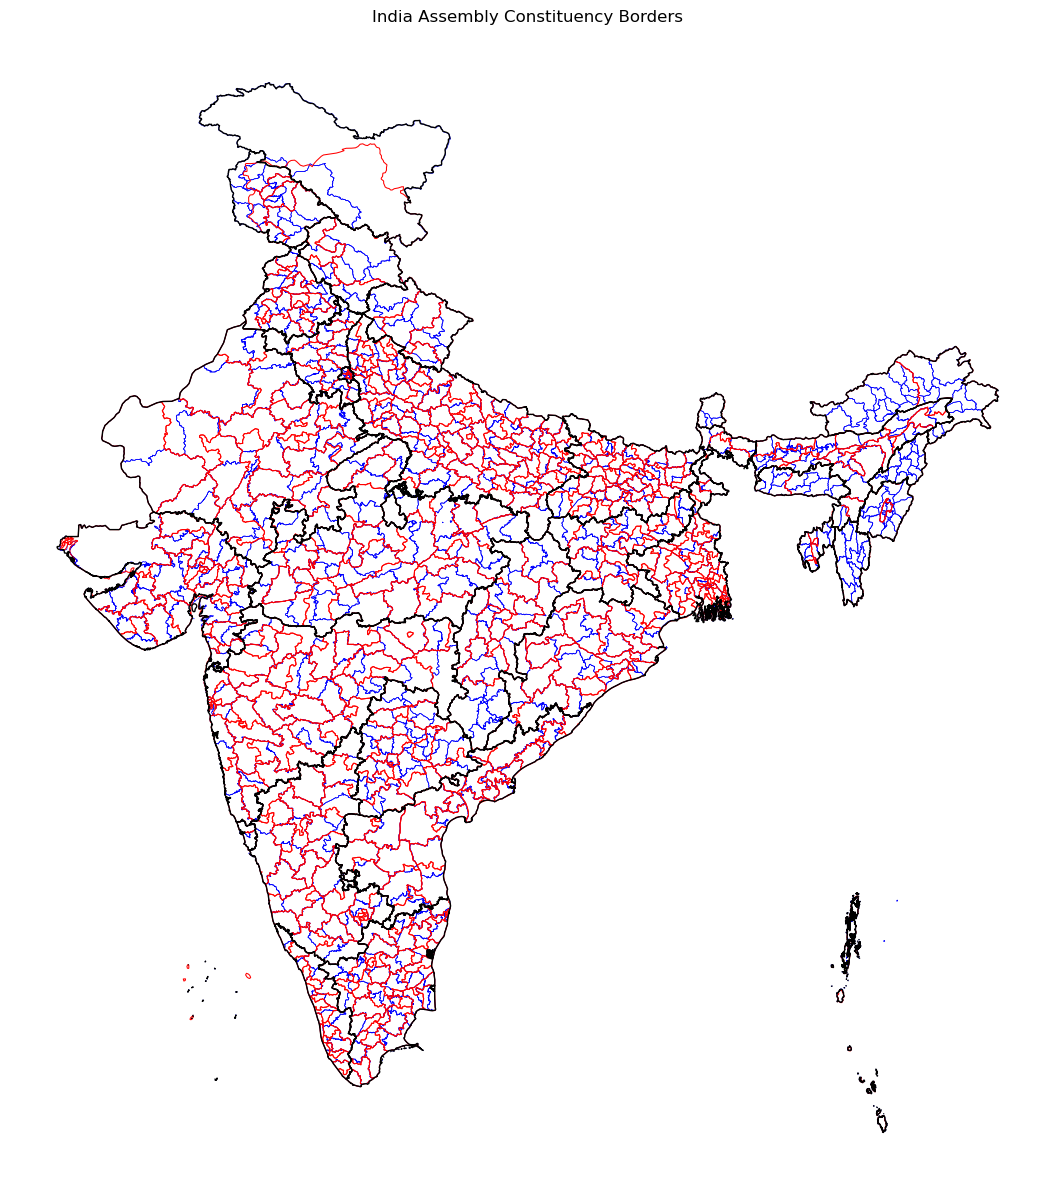

In [108]:
import geopandas as gpd
import os

# Load the GeoJSON file into a GeoDataFrame
new_ac_file_path= os.path.join(proj_folder, "shape-files/3.cleaned/india_ac_cleaned-V3.geojson")
ac_gdf = gpd.read_file(new_ac_file_path)
dist_file_path = os.path.join(proj_folder, dist_geo_file)
dist_gdf = gpd.read_file(dist_file_path)
pc_file_path= os.path.join(proj_folder, pc_geo_file)
pc_gdf = gpd.read_file(pc_file_path)
states_gdf = gpd.read_file(st_file_path)


# Create a plot
fig, ax = plt.subplots(figsize=(15, 15))
# Set the background color of the figure
fig.patch.set_facecolor('white')  # Change 'lightblue' to your preferred color

# Plot the districts with a thin border
# ac_gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.15)

# Plot the state borders with a thicker line
dist_gdf.boundary.plot(ax=ax, edgecolor='blue', linewidth=0.5)
pc_gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=0.75)
states_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# Remove the axis for a cleaner look
ax.axis('off')
# Set the title
plt.title('India Assembly Constituency Borders')
# Display the plot
plt.show()

# 3A. Export the attributes to Excel for manual editing:
ac_gdf = ac_gdf[[ 'ST_NAME', 'ST_UID', 'PC_UID', 'PC_NAME', 'DT_UID', 'DT_NAME', 'AC_UID', 'AC_NAME']].drop_duplicates()
ac_gdf = ac_gdf.sort_values(by=['ST_NAME','PC_NAME','AC_NAME', 'DT_NAME']).reset_index(drop=True)


# 3B. Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(shapefiles_interim, 'ac_geo_uid_final.xlsx')
ac_gdf.to_excel(output_file_path, sheet_name="ac-geo-uid", index=False)


## Prepare Excel with Same Unique IDs for PC
2019
2014
2009

In [14]:
import pandas as pd

# Load the GeoJSON file into a GeoDataFrame
xl_file_path= os.path.join(proj_folder, "election_data/GE for 2019_2014 & 2009.xlsx")
df_2019 = pd.read_excel(xl_file_path, sheet_name="2019")


# Sort the DataFrame by 'st_id' and 'dtname'
df_2019 = df_2019.sort_values(by=['ST_UNIQUE_ID', 'Constituency_Name_as_per_ECI']).reset_index(drop=True)

# Group by 'st_id' and create a serial number for each district within each group
df_2019['serial_no'] = df_2019.groupby('ST_UNIQUE_ID').cumcount() + 1

# Convert the serial number to a string and pad with zeros to have four digits
df_2019['serial_no'] = df_2019['serial_no'].astype(str).str.zfill(3)

# Create the unique ID string by concatenating 'st_id' and the zero-padded serial number
df_2019['PC_UNIQUE_ID'] = df_2019['ST_UNIQUE_ID'] + '-P' + df_2019['serial_no']

# Drop the 'serial_no' column as it is no longer needed
df_2019 = df_2019.drop(columns=['serial_no'])


# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(proj_folder, "election_data/pc_tcpd_data.xlsx")
df_2019.to_excel(output_file_path, sheet_name="LS_2019")

print('new Excel saved')
# print(df_2014['PC_UNIQUE_ID'].drop_duplicates()
##############

# Export excel with geo unique ids for cross-check and verification

df = df_2019[['PC_UNIQUE_ID', 'Constituency_Name_as_per_ECI']].drop_duplicates()

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(proj_folder, "election_data/pc_tcpd_uid.xlsx")
df.to_excel(output_file_path, sheet_name="2019")

print('TCPD - PC UID Excel 2019 Saved')

print('Finito')


KeyError: 'ST_UNIQUE_ID'

In [28]:
import pandas as pd

# Load the GeoJSON file into a GeoDataFrame
xl_file_path= os.path.join(proj_folder, "election_data/GE for 2019_2014 & 2009.xlsx")
df_2014 = pd.read_excel(xl_file_path, sheet_name="2014")


# Add a new property 'new_property' with a default value
df_2014['ST_UNIQUE_ID'] = df_2014['ST_ABB_AUTHORS'] + '-' + df_2014['ST_CODE_AUTHORS']

# Sort the DataFrame by 'st_id' and 'dtname'
df_2014 = df_2014.sort_values(by=['ST_UNIQUE_ID', 'Constituency_Name_as_per_ECI']).reset_index(drop=True)

# Group by 'st_id' and create a serial number for each district within each group
df_2014['serial_no'] = df_2014.groupby('ST_UNIQUE_ID').cumcount() + 1

# Convert the serial number to a string and pad with zeros to have four digits
df_2014['serial_no'] = df_2014['serial_no'].astype(str).str.zfill(3)

# Create the unique ID string by concatenating 'st_id' and the zero-padded serial number
df_2014['PC_UNIQUE_ID'] = df_2014['ST_UNIQUE_ID'] + '-P' + df_2014['serial_no']

# Drop the 'serial_no' column as it is no longer needed
df_2014 = df_2014.drop(columns=['serial_no'])


# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(proj_folder, "election_data/pc_tcpd_data.xlsx")
df_2014.to_excel(output_file_path, sheet_name="LS_2014")

print('new Excel saved')
# print(df_2014['PC_UNIQUE_ID'].drop_duplicates()
##############

# Export excel with geo unique ids for cross-check and verification

df = df_2014[['PC_UNIQUE_ID', 'Constituency_Name_as_per_ECI']].drop_duplicates()

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(proj_folder, "election_data/pc_tcpd_uid.xlsx")
df.to_excel(output_file_path, sheet_name="2014")

print('TCPD - PC UID Excel 2014 Saved')

print('Finito')


new Excel saved
TCPD - PC UID Excel 2014 Saved
Finito


In [27]:
import pandas as pd

# Load the GeoJSON file into a GeoDataFrame
xl_file_path= os.path.join(proj_folder, "election_data/GE for 2019_2014 & 2009.xlsx")
df_2009 = pd.read_excel(xl_file_path, sheet_name="2009")

# Add a new property 'new_property' with a default value
df_2009['ST_UNIQUE_ID'] = df_2009['ST_ABB_AUTHORS'] + '-' + df_2009['ST_CODE_AUTHORS']

# Sort the DataFrame by 'st_id' and 'dtname'
df_2009 = df_2009.sort_values(by=['ST_UNIQUE_ID', 'Constituency_Name_as_per_ECI']).reset_index(drop=True)

# Group by 'st_id' and create a serial number for each district within each group
df_2009['serial_no'] = df_2009.groupby('ST_UNIQUE_ID').cumcount() + 1

# Convert the serial number to a string and pad with zeros to have four digits
df_2009['serial_no'] = df_2009['serial_no'].astype(str).str.zfill(3)

# Create the unique ID string by concatenating 'st_id' and the zero-padded serial number
df_2009['PC_UNIQUE_ID'] = df_2009['ST_UNIQUE_ID'] + '-P' + df_2009['serial_no']

# Drop the 'serial_no' column as it is no longer needed
df_2009 = df_2009.drop(columns=['serial_no'])


# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(proj_folder, "election_data/pc_tcpd_data.xlsx")
df_2009.to_excel(output_file_path, sheet_name="LS_2009")

print('new Excel saved')
# print(df_2009['PC_UNIQUE_ID'].drop_duplicates()
##############

# Export excel with geo unique ids for cross-check and verification

df = df_2009[['PC_UNIQUE_ID', 'Constituency_Name_as_per_ECI']].drop_duplicates()

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(proj_folder, "election_data/pc_tcpd_uid.xlsx")
df.to_excel(output_file_path, sheet_name="2009")

print('TCPD - PC UID Excel 2009 Saved')

print('Finito')

new Excel saved
TCPD - PC UID Excel 2009 Saved
Finito


In [29]:
import pandas as pd

# # Load the GeoJSON file into a GeoDataFrame
# xl_file_path= os.path.join(proj_folder, "election_data/GE for 2019_2014 & 2009.xlsx")
# df_2019 = pd.read_excel(xl_file_path, sheet_name="2019")
# df_2014 = pd.read_excel(xl_file_path, sheet_name="2014")
# df_2009 = pd.read_excel(xl_file_path, sheet_name="2009")

# stack data
df_pc_tcpd = pd.concat([df_2019,df_2014,df_2009],ignore_index=True)


# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(proj_folder, "election_data/pc_tcpd_full_data.xlsx")
df_pc_tcpd.to_excel(output_file_path, sheet_name="Consolidated")

print('new Excel saved')
# print(df_2009['PC_UNIQUE_ID'].drop_duplicates()
##############

# Export excel with geo unique ids for cross-check and verification

df = df_pc_tcpd[['PC_UNIQUE_ID', 'Constituency_Name_as_per_ECI']].drop_duplicates()

# Save the modified GeoDataFrame back to a GeoJSON file
output_file_path= os.path.join(proj_folder, "election_data/pc_tcpd_uid_full.xlsx")
df.to_excel(output_file_path, sheet_name="full")

print('TCPD - PC UID Full Excel Saved')

print('Finito')


new Excel saved
TCPD - PC UID Full Excel Saved
Finito


In [41]:
import pandas as pd
import os
# Load the GeoJSON file into a GeoDataFrame
geo_id_file_path = os.path.join(proj_folder, "shape-files/2.interim/ac_geo_uid_final.xlsx")
geo_df = pd.read_excel(geo_id_file_path, sheet_name="ac-geo-uid")

geo_dist_df = geo_df[['ST_UID', 'DT_UID', 'ST_NAME', 'DT_NAME']].drop_duplicates(subset=['ST_UID', 'DT_UID'], keep='first')
geo_dist_df = geo_dist_df[['ST_NAME', 'DT_NAME','ST_UID', 'DT_UID']].sort_values(by=['ST_UID', 'DT_UID'], ascending=[True, True] )

# print(geo_dist_df)
# Save the modified geo ids back to a excel file
output_file_path= os.path.join(shapefiles_interim, 'ac_geo_uid_for_matching.xlsx')
geo_dist_df[['ST_NAME', 'DT_NAME','ST_UID', 'DT_UID']].to_excel(output_file_path, sheet_name="dist-geo-uid", index=False)
print('Done')

Done
